# 第4章: 言語解析

問題30から問題35までは、以下の文章`text`（太宰治の『走れメロス』の冒頭部分）に対して、言語解析を実施せよ。問題36から問題39までは、国家を説明した文書群（日本語版ウィキペディア記事から抽出したテキスト群）をコーパスとして、言語解析を実施せよ。

In [ ]:
text = """
メロスは激怒した。
必ず、かの邪智暴虐の王を除かなければならぬと決意した。
メロスには政治がわからぬ。
メロスは、村の牧人である。
笛を吹き、羊と遊んで暮して来た。
けれども邪悪に対しては、人一倍に敏感であった。
"""

## 30. 動詞
文章`text`に含まれる動詞をすべて表示せよ。

In [ ]:
!pip install janome

In [ ]:
from janome.tokenizer import Tokenizer

t = Tokenizer()

# 文章を単語ごとに分割して品詞を確認する
for token in t.tokenize(text):
  res = token.part_of_speech.split(",")

  if (res[0] == "動詞"):
    print(token.surface)

し
除か
なら
し
わから
吹き
遊ん
暮し
来


## 31. 動詞の原型
文章`text`に含まれる動詞と、その原型をすべて表示せよ。

In [ ]:
for token in t.tokenize(text):
  res = token.part_of_speech.split(",")

  if (res[0] == "動詞"):
    print(token.base_form)

する
除く
なる
する
わかる
吹く
遊ぶ
暮す
来る


## 32. 「AのB」
文章`text`において、2つの名詞が「の」で連結されている名詞句をすべて抽出せよ。

In [ ]:
data = t.tokenize(text)
res = []

for i,token in enumerate(data):
  part_of_speech = token.part_of_speech.split(",")[0]   # 品詞
  res.append([token.surface, part_of_speech])

  if (len(res) >= 3):

    if (res[1][0] == "の"):
      if (res[0][1] == "名詞") and (res[2][1] == "名詞"):
        print(res[0][0])
        print(res[2][0])

    del res[0]

暴虐
王
村
牧人


## 33. 係り受け解析

文章`text`に係り受け解析を適用し、係り元と係り先のトークン（形態素や文節などの単位）をタブ区切り形式ですべて抽出せよ。

In [ ]:
!pip install -U ginza ja-ginza

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.1/59.1 MB 19.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.2/72.2 MB 10.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 75.2 MB/s eta 0:00:00


In [ ]:
import spacy

# エラーを回避するための設定（config）を定義
config = {
    "components": {
        "compound_splitter": {
            "split_mode": "C",
        }
    }
}

# configを渡してGiNZA（日本語モデル）を読み込む
nlp = spacy.load("ja_ginza", config=config)

In [ ]:
# 2. 解析したいテキストを渡す
doc = nlp(text.replace("\n", ""))

# 3. 係り受けの結果を1単語ずつ取り出して表示する
for token in doc:
    # token.text      : その単語（係り元）
    # token.head.text : どこにかかっているか（係り先）
    print(f"{token.text}\t{token.head.text}")

メロス	激怒
は	メロス
激怒	激怒
し	激怒
た	激怒
。	激怒
必ず	除か
、	必ず
かの	暴虐
邪智	暴虐
暴虐	王
の	暴虐
王	除か
を	王
除か	決意
なけれ	除か
ば	なけれ
なら	なけれ
ぬ	なけれ
と	除か
決意	決意
し	決意
た	決意
。	決意
メロス	わから
に	メロス
は	メロス
政治	わから
が	政治
わから	わから
ぬ	わから
。	わから
メロス	牧人
は	メロス
、	メロス
村	牧人
の	村
牧人	牧人
で	牧人
ある	で
。	牧人
笛	吹き
を	笛
吹き	暮し
、	吹き
羊	遊ん
と	羊
遊ん	暮し
で	遊ん
暮し	暮し
て	暮し
来	て
た	暮し
。	暮し
けれど	敏感
も	けれど
邪悪	敏感
に	邪悪
対し	に
ては	に
、	邪悪
人	倍
一	倍
倍	敏感
に	倍
敏感	敏感
で	敏感
あっ	で
た	敏感
。	敏感


## 34. 主述の関係
文章`text`において、「メロス」が主語であるときの述語を抽出せよ。

In [ ]:
# 2. 解析したいテキストを渡す
doc = nlp(text.replace("\n", ""))

# 3. 係り受けの結果を1単語ずつ取り出して表示する
for token in doc:
    # token.dep_ : 依存関係ラベル
    # nsubj -> Nominal Subject 主語
    if (token.dep_ == "nsubj") and (token.text == "メロス"):
      print(token.head.text)

激怒
牧人


## 35. 係り受け木
「メロスは激怒した。」の係り受け木を可視化せよ。

In [ ]:
from spacy import displacy

text = "メロスは激怒した。"
doc = nlp(text)

displacy.render(doc,
                style="dep"   # 描画スタイルの指定　dep -> 係り受け
                )

## 36. 単語の出現頻度

問題36から39までは、Wikipediaの記事を以下のフォーマットで書き出したファイル[jawiki-country.json.gz](/data/jawiki-country.json.gz)をコーパスと見なし、統計的な分析を行う。

* 1行に1記事の情報がJSON形式で格納される
* 各行には記事名が"title"キーに、記事本文が"text"キーの辞書オブジェクトに格納され、そのオブジェクトがJSON形式で書き出される
* ファイル全体はgzipで圧縮される

まず、第3章の処理内容を参考に、Wikipedia記事からマークアップを除去し、各記事のテキストを抽出せよ。そして、コーパスにおける単語（形態素）の出現頻度を求め、出現頻度の高い20語とその出現頻度を表示せよ。

In [ ]:
!pip install mecab-python3 unidic-lite

In [ ]:
import re
import json

import MeCab
from collections import Counter

In [ ]:
word_counts = Counter()   # 単語の出現回数を数えるための辞書型オブジェクト
t = Tokenizer()

# 日本語のみを表す正規表現
pattern = re.compile(r"[一-龥ぁ-んァ-ヶ]")

with open("jawiki-country.json", 'r') as f:
  for line in f:
      line = json.loads(line)["text"]
      data = t.tokenize(line)   # 単語のリストに分解

      for word in data:
        res = word.part_of_speech.split(",")
        pos = res[0]    # 品詞
        original = word.base_form   # 基本形

        # 名詞・動詞・形容詞のいずれか　かつ　その単語に日本語が含まれているか
        if ((pos in ["名詞", "動詞", "形容詞"]) and (bool(pattern.search(original)) == True)):
          word_counts[(original, pos)] += 1

for i, ((word, pos), count) in enumerate(word_counts.most_common(20), 1):
    print(f"{i}: {word} ({count}回)")

1: する (48174回)
2: 年 (30229回)
3: れる (18574回)
4: いる (17519回)
5: 月 (13705回)
6: 日 (10508回)
7: 人 (10135回)
8: 国 (9082回)
9: なる (7570回)
10: ある (5835回)
11: 語 (5803回)
12: 的 (5263回)
13: 世界 (4819回)
14: こと (4642回)
15: リンク (4414回)
16: 日本 (4343回)
17: 大統領 (4056回)
18: 政府 (3646回)
19: ため (3551回)
20: 州 (3440回)


## 37. 名詞の出現頻度
コーパスにおける名詞の出現頻度を求め、出現頻度の高い20語とその出現頻度を表示せよ。

In [ ]:
i = 0

for ((word, pos), count) in word_counts.most_common(50):

  if (pos == "名詞"):
    i += 1
    print(f"{i}: {word} ({count}回)")

    if (i >= 20):
      break

1: 年 (30229回)
2: 月 (13705回)
3: 日 (10508回)
4: 人 (10135回)
5: 国 (9082回)
6: 語 (5803回)
7: 的 (5263回)
8: 世界 (4819回)
9: こと (4642回)
10: リンク (4414回)
11: 日本 (4343回)
12: 大統領 (4056回)
13: 政府 (3646回)
14: ため (3551回)
15: 州 (3440回)
16: 島 (3359回)
17: 共和 (3351回)
18: 者 (3312回)
19: 経済 (3227回)
20: 人口 (2964回)


## 38. TF・IDF
日本に関する記事における名詞のTF・IDFスコアを求め、TF・IDFスコア上位20語とそのTF, IDF, TF・IDFを表示せよ。

In [ ]:
import math

In [ ]:
import json
import re
import math
from janome.tokenizer import Tokenizer

t = Tokenizer()

japan = {}
others = {}
total_docs = 0
total = 0

pattern = re.compile(r"[一-龥ぁ-んァ-ヶ]")

with open("jawiki-country.json", 'r') as f:
    for line in f:
        line = json.loads(line)
        total_docs += 1

        # 記事から、条件を満たす名詞（基本形）のリストを作る
        valid_nouns = []
        for word in t.tokenize(line["text"]):
            pos = word.part_of_speech.split(",")[0]
            base = word.base_form

            if (base == "*"):
              base = word.surface

            if (pos == "名詞" and bool(pattern.search(base))):
                valid_nouns.append(base)

        # 日本の記事の場合、出現回数をカウント
        if line["title"] == "日本":
            for noun in valid_nouns:
                japan[noun] = japan.get(noun, 0) + 1
                total += 1

        # 日本以外の記事の場合、出現した名詞の重複を削除し、カウント
        else:
            for noun in set(valid_nouns): # set()で重複を削除
                # japan.get(noun, 0) -> japan の中に noun があるか探し、あれば数値を、なければ0を返す
                others[noun] = others.get(noun, 0) + 1


tf_idf_score = []
# TF = (ある単語の出現回数​) / (その文書内の全単語数)
# IDF = log(全文書数 / その単語が含まれる文書数​) + 1
# TF-IDF = TF * IDF

for word in japan:
    tf = japan[word] / total

    # その単語が含まれる文書数は、他記事での出現数 ＋ 1（日本の記事自身）
    doc_count = others.get(word, 0) + 1
    idf = math.log(total_docs / doc_count) + 1

    tf_idf_score.append((tf * idf, tf, idf, word))

tf_idf_score.sort(reverse=True)

print("単語\t\tTF-IDF\t\tTF\t\tIDF")
for data in tf_idf_score[:20]:
    print(f"{data[3]}\t\t{data[0]:.4f}\t\t{data[1]:.4f}\t\t{data[2]:.4f}")

単語		TF-IDF		TF		IDF
日本		0.0365		0.0327		1.1153
年		0.0293		0.0291		1.0081
日		0.0119		0.0116		1.0286
月		0.0115		0.0112		1.0204
県		0.0097		0.0064		1.5298
国		0.0093		0.0092		1.0122
天皇		0.0093		0.0026		3.6231
琉球		0.0090		0.0017		5.4148
的		0.0080		0.0077		1.0412
倭		0.0079		0.0015		5.1271
倭国		0.0078		0.0013		5.8203
中国		0.0071		0.0042		1.7012
沖縄		0.0067		0.0018		3.7408
朝鮮		0.0066		0.0018		3.6231
世界		0.0063		0.0060		1.0370
人		0.0061		0.0060		1.0204
列島		0.0059		0.0014		4.1155
日本書紀		0.0059		0.0009		6.5134
こと		0.0057		0.0055		1.0370
韓国		0.0056		0.0022		2.5816


## 39. Zipfの法則
コーパスにおける単語の出現頻度順位を横軸、その出現頻度を縦軸として、両対数グラフをプロットせよ。

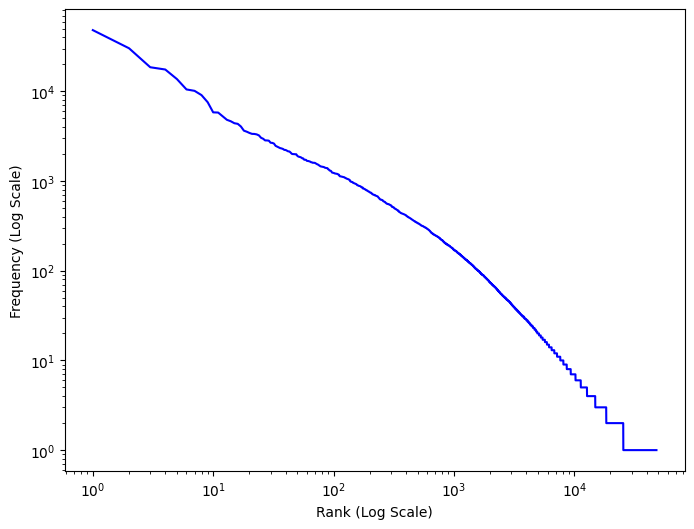

In [ ]:
import matplotlib.pyplot as plt

# word_counts からグラフ用のデータを抽出する
frequencies = []

# most_common() 頻度が高い順
# word_counts = [((単語, 品詞), 回数), ((単語, 品詞), 回数), ...]
for item, count in word_counts.most_common():
    frequencies.append(count)

# 順位（Rank）のリストを作ります。1位から始まり、単語の種類数まで連番を作る
ranks = range(1, len(frequencies) + 1)


# グラフの描画
# グラフのサイズを設定
plt.figure(figsize=(8, 6))

# 両対数グラフのプロット
plt.loglog(ranks, frequencies, color='b')

# グラフのタイトルと軸ラベルを設定
plt.xlabel("Rank (Log Scale)")
plt.ylabel("Frequency (Log Scale)")


# グラフを画面に表示
plt.show()